In [29]:
import Bisection as Bi
import Newton_Raphson as NR
import numpy as np
import matplotlib.pyplot as plt

In [30]:
x = np.linspace(-5, 5, 2000)
points = [(-8, 0), (-4,0), (0, 0), (2, 0), (6, 0)]
y = x**2 + 5

min_distances = []
point_xs = []

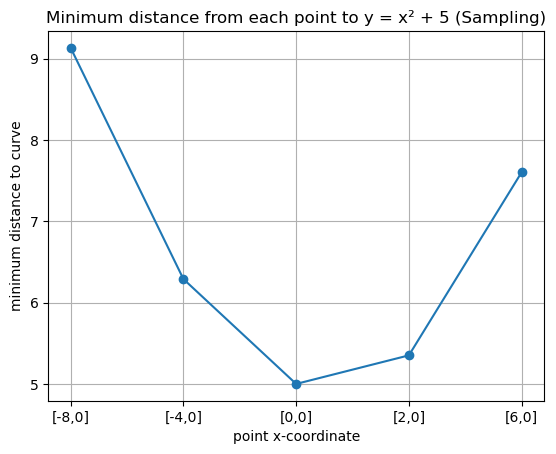

In [31]:
min_distances = []
point_xs = []

for x0, y0 in points:
    d = np.sqrt((x - x0)**2 + (y - y0)**2)
    min_distances.append(np.min(d))
    point_xs.append(x0)

fig, ax = plt.subplots()

ax.plot(x_plot, min_distances, marker="o")
ax.set_xlabel("point x-coordinate")
ax.set_ylabel("minimum distance to curve")
ax.set_title("Minimum distance from each point to y = x² + 5 (Sampling)")
ax.grid(True)

plt.savefig("sampling_fixed.png")
plt.show()


In [32]:
dis_Bi = []
for x0, y0 in points:
    min_dist, x_min = Bi.golden_section_search(x0, y0, lambda x:x**2+5, -5,5)
    dis_Bi.append(min_dist)

    

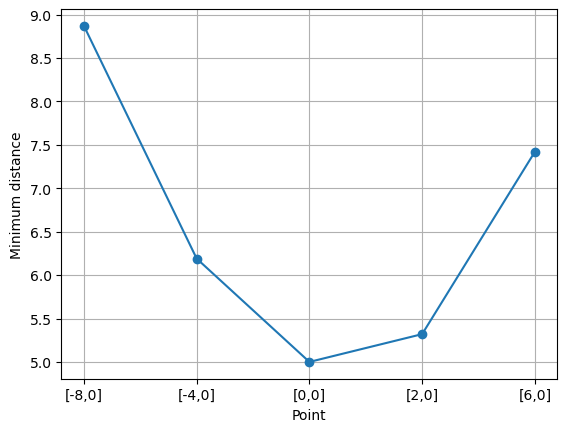

In [33]:
#Analytical:
x_plot = ["[-8,0]", "[-4,0]", "[0,0]", "[2,0]", "[6,0]"]
y_ana = np.array([8.87, 6.19,5,5.32,7.42])

fig, ax = plt.subplots()
ax.plot(x_plot,y_ana, marker ="o")
ax.set_xlabel("Point")
ax.set_ylabel("Minimum distance")
ax.grid()

plt.savefig("analytical")
plt.show()


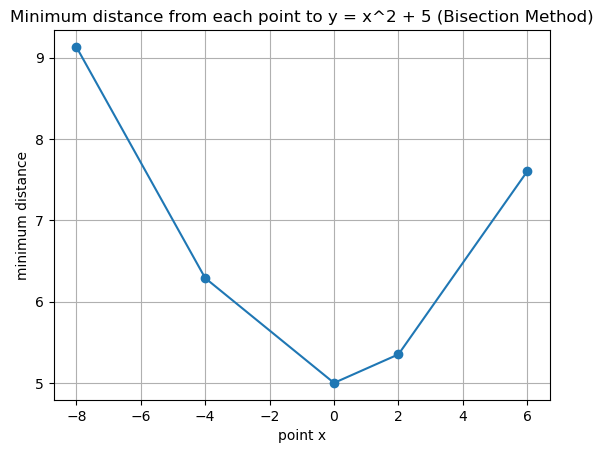

In [34]:
x_points = [p[0] for p in points]
plt.plot(x_points, dis_Bi, marker ='o')
plt.xlabel("point x")
plt.ylabel("minimum distance")
plt.title("Minimum distance from each point to y = x^2 + 5 (Bisection Method)")
plt.grid()
plt.savefig("Bisection code_first function")
plt.show()


In [35]:
dis_NR = []
for x0, y0 in points:
    min_dist, x_min = NR.find_distance_newton(x0 = x0,y0 =  y0,f = lambda x:x**2+5, df =lambda x: 2*x,  ) #update function handle
    dis_NR.append(min_dist)

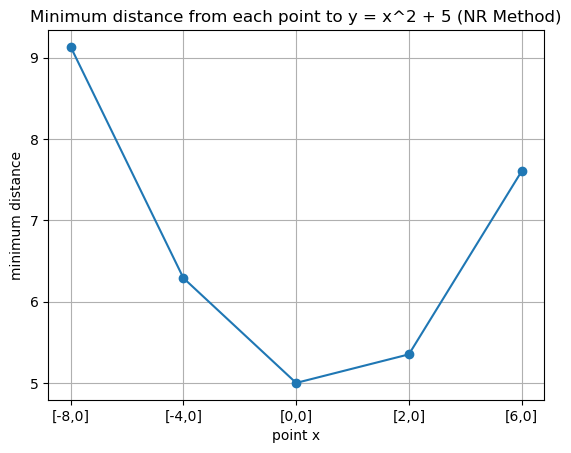

In [36]:

plt.plot(x_plot, dis_NR, marker ='o')
plt.xlabel("point x")
plt.ylabel("minimum distance")
plt.title("Minimum distance from each point to y = x^2 + 5 (NR Method)")
plt.grid()
plt.show()

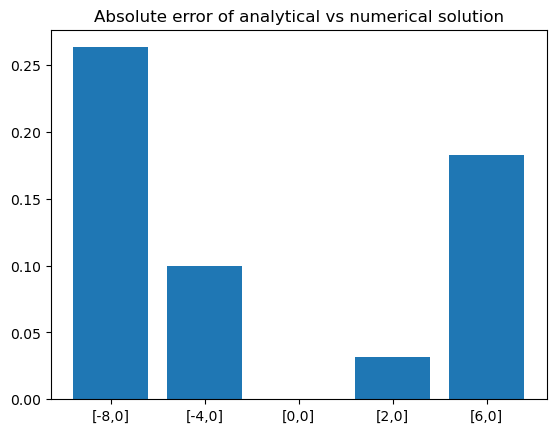

In [46]:
dis_NR = np.array(dis_NR)
dis_Bi = np.array(dis_Bi)
#Error:
fig,ax = plt.subplots()

ax.bar(x_plot,abs(y_ana - dis_NR))
ax.set_title("Absolute error of analytical vs numerical solution")

plt.savefig("Error of Analytical vs NR")
